Automated Exam Oversight via Object Detection and Gaze Estimation

In [2]:
import pandas as pd
import json
import zipfile
import os

c:\Users\ashis\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
import cv2
import matplotlib.pyplot as plt

In [4]:
from sklearn.utils import shuffle

In [2]:
#Loading the dataset

In [3]:
path = 'Online Proctoring System.coco.zip'

The Online Proctoring System dataset, exported from Roboflow in March 2026, is a specialized computer vision collection consisting of 12,313 total annotations concentrated within a single train/ directory. The dataset is professionally structured in the COCO format, using a high-definition resolution of 1280x720 pixels to ensure small objects like mobile devices are clearly visible. According to the class distribution, the data is dominated by 9,313 "person" labels, providing a massive baseline for tracking student presence and posture. Crucially for academic integrity, it includes 2,477 "cell phone" instances and 523 "laptop" detections, allowing a YOLOv8 model to distinguish between the primary workstation and unauthorized secondary devices.

In [6]:
extract_dir = 'proctor__dataset'
with zipfile.ZipFile(path, 'r') as z:
    z.extractall(extract_dir)
print(f"Extraction complete! Files saved to: {extract_dir}")

json_path = os.path.join(extract_dir, 'train', '_annotations.coco.json')
with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

image_map = {img['id']: img['file_name'] for img in data['images']}
category_map = {cat['id']: cat['name'] for cat in data['categories']}

rows = []
for ann in data['annotations']:
    bbox = ann['bbox']
    
    try:
        xmin = float(bbox[0])
        ymin = float(bbox[1])
        w    = float(bbox[2])
        h    = float(bbox[3])
        
        rows.append({
            'frame': image_map.get(ann['image_id'], "Unknown"),
            'xmin': int(xmin),
            'xmax': int(xmin + w), 
            'ymin': int(ymin),
            'ymax': int(ymin + h), 
            'class_id': ann['category_id'],
            'label_name': category_map.get(ann['category_id'], "Unknown")
        })
    except (ValueError, TypeError):
        continue 

csv_output = 'proctor__labels.csv'
df = pd.DataFrame(rows)
df.to_csv(csv_output, index=False)



Extraction complete! Files saved to: proctor__dataset


By converting the raw metadata from the _annotations.coco.json file into a flat CSV format, we have transformed the complex [x, y, width, height] coordinates into a simplified xmin, xmax, ymin, ymax structure

In YOLO (You Only Look Once), prediction accuracy depends entirely on how well the model understands the spatial boundaries of an object. Converting your data into a simplified CSV format with xmin, xmax, ymin, and ymax is a critical preparation step for the YOLO pipeline.

In [5]:
df=pd.read_csv('proctor__labels.csv')

In [6]:
df.head()

,frame,xmin,xmax,ymin,ymax,class_id,label_name
0,final 2_mp4-4018_jpg.rf.YovuLA8VsoFVw8eLTbEc.jpg,300,1009,89,720,3,person
1,final 2_mp4-8520_jpg.rf.ZzoipY9QRdkiKcrhgBfq.jpg,388,853,162,720,3,person
2,final 2_mp4-8520_jpg.rf.ZzoipY9QRdkiKcrhgBfq.jpg,717,1057,469,717,1,cell phone
3,final 2_mp4-5150_jpg.rf.dMHBAMN5tceUz1xnVOrx.jpg,129,795,65,720,3,person
4,final 2_mp4-5150_jpg.rf.dMHBAMN5tceUz1xnVOrx.jpg,898,1280,66,542,3,person


In [7]:
df = shuffle(df)
labels = {0: 'objects', 1: 'cell phone', 2: 'laptop', 3: 'person'}

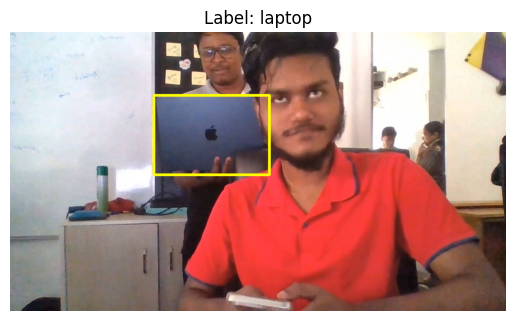

In [8]:

row = df.iloc[2] 
img_path = os.path.join('proctor__dataset/train', row['frame'])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

cv2.rectangle(img, (row['xmin'], row['ymin']), (row['xmax'], row['ymax']), (255, 255, 0), 5)

plt.imshow(img)
plt.title(f"Label: {row['label_name']}")
plt.axis('off')
plt.show()

Model Building

In [14]:
#!pip install ultralytics

  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 4.0 MB/s eta 0:00:00
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
   ---------------------------------------- 0.0/810.4 kB ? eta -:--:--
   ------------------------- -------------- 524.3/810.4 kB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 810.4/810.4 kB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/45.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/45.7 MB 4.2 MB/s eta 0:00:11
    --------------------------------------- 0.8/45.7 MB 4.2 MB/s eta 0:00:11
   - -------------------------------------- 1.3/45.7 MB 2.9 MB/s eta

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.16.0rc0 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.16.0rc0 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.16.0rc0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.5 which is incompatible.
tensorflow-intel 2.16.0rc0 requires tensorboard<2.17,>=2.16, but you have tensorboard 2.20.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from ultralytics import YOLO

In [11]:
model = YOLO("yolov8m.pt")


image 1/1 c:\Users\ashis\VisionProctor\proctor__dataset\train\final 2_mp4-2319_jpg.rf.NFjE6wzp1JmlgTwIsavo.jpg: 384x640 2 persons, 4 chairs, 1 couch, 549.9ms
Speed: 32.3ms preprocess, 549.9ms inference, 19.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\ashis\VisionProctor\runs\detect\predict


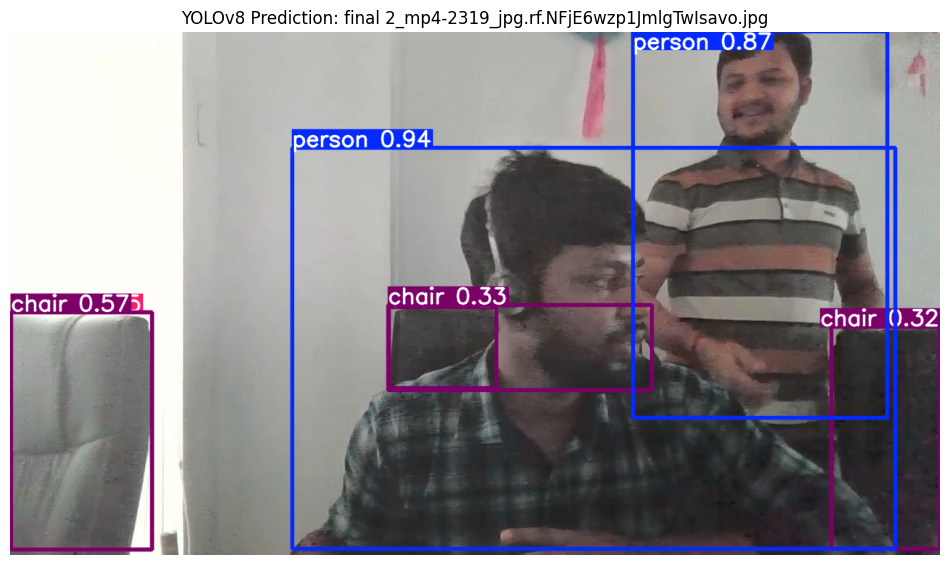

In [12]:
folder_path = 'proctor__dataset/train'
file_name = df.iloc[5]['frame']
test_image = os.path.join(folder_path, file_name)

if not os.path.exists(test_image):
    print(f" File not found: {test_image}")
else:
    results = model.predict(source=test_image, save=True, conf=0.2, iou=0.5)

    plot = results[0].plot() 
    plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12,8))
    plt.imshow(plot)
    plt.title(f"YOLOv8 Prediction: {file_name}")
    plt.axis('off')
    plt.show()